# One-Class SVM

Entraîner un modèle One-Class SVM sur les features préparées. Comparer avec l'Isolation Forest sur les mêmes données. Analyser les temps d'entraînement et les résultats.

## Définition

Le One-Class SVM est un algorithme de détection d'anomalies non supervisé basé sur les machines à vecteurs de support (SVM). Contrairement aux SVM classiques qui séparent deux classes, le One-Class SVM apprend uniquement à partir des données normales et cherche à tracer une frontière autour d'elles dans un espace de features transformé ainsi tout point situé en dehors de cette frontière est considéré comme une anomalie.

## Principe de l'algorithme

L'algorithme fonctionne en trois étapes :
- Transformation des données : les données sont projetées dans un espace mathématique où les points normaux se regroupent naturellement ensemble, rendant les anomalies plus faciles à repérer.
- Tracé d'une frontière : l'algorithme trace la frontière la plus large possible autour des données normales, en s'assurant qu'elle les englobe au maximum.
- Classification : tout nouveau point qui tombe en dehors de cette frontière est considéré comme une anomalie.

## Paramètres clés utilisés

- nu est le paramètre principal et équivalent au taux de contamination de l'Isolation Forest. Il représente la proportion maximale d'anomalies acceptée et contrôle le compromis entre faux positifs et faux négatifs.

- kernel est la fonction de transformation des données. On utilise ici rbf (Radial Basis Function), le plus courant pour des données non linéaires.

- Le recall mesure la capacité du modèle à retrouver toutes les anomalies réelles 
- La précision indique parmi toutes les alertes levées combien sont de vraies attaques.
- Le f1-score est la moyenne harmonique des deux ainsi il synthétise en un seul chiffre le compromis entre précision et recall.
- L'accuracy représente le taux de bonnes classifications global.

## Importation des librairies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
chemin_CICIDS = '../Data/cicids_clean.csv'
chemin_UNSW   = '../Data/unsw_clean.csv'
chemin_LOGS   = '../Data/logs_clean.csv'

df_cicids = pd.read_csv(chemin_CICIDS, low_memory=False)
df_unsw   = pd.read_csv(chemin_UNSW,low_memory=False)
df_logs   = pd.read_csv(chemin_LOGS,low_memory=False)



## Dataset 1 : CIC-IDS-2017

### 1.1 Préparation des données

Le dataset CICIDS contient envrion 220 000 lignes, ce qui est trop lourd pour le One-Class SVM donc on va travaillre sur un échantillon de 10 000 points pour conserver la proportion réelle d'attaques.

In [4]:
from sklearn.model_selection import train_test_split  # pour créer un échantillon avec la même proportion

X = df_cicids.drop(columns=['Label']).select_dtypes(include=[np.number])  # on garde uniquement les colonnes numériques sans le label
y = (df_cicids['Label'] != 'BENIGN').astype(int)  # 0 pour normal et  1 pour attaque
X = X.fillna(0).replace([np.inf, -np.inf], 0)  # on remplace les valeurs manquantes et infinies par 0
X_scaled = StandardScaler().fit_transform(X)  # normalisation donc met toutes les features à la même échelle
X_cicids_sample, _, y_cicids_sample, _ = train_test_split(X_scaled, y, train_size=10000, stratify=y, random_state=42) # on garde 10 000 points en respectant les proportions des classes (stratify=y)

print(f"Taille échantillon : {X_cicids_sample.shape}")       
print(f"Proportion d'attaques : {y_cicids_sample.mean():.2%}") 

Taille échantillon : (10000, 79)
Proportion d'attaques : 57.38%


On a bien 10 000 points avec 79 features et 57.38 % d'attaques.

### 1.2 Entraînement et comparaison

La contamination de l'Isolation Forest accepte uniquement des valeurs entre 0.0 et 0.5 maximum ainsi 0.57 est hors limites, pour cela on pose nu et contamination à 0.5.

In [5]:
# One-Class SVM
t0 = time.time()
svm = OneClassSVM(kernel='rbf', nu=0.5, gamma='scale')  # on pose nu=0.5 étant la proportion d'attaques
pred_svm = (svm.fit_predict(X_cicids_sample) == -1).astype(int)  # -1 pour une anomalie devient 1 sinon devient 0
t_svm = time.time() - t0  # on calcule le temps d'entraînement

# Isolation Forest avec le même échantillon 
t0 = time.time()
iforest = IsolationForest(contamination=0.5, random_state=42, n_jobs=-1)  # contamination même valeur que nu
pred_if = (iforest.fit_predict(X_cicids_sample) == -1).astype(int)
t_if = time.time() - t0

print(f"Temps One-Class SVM : {t_svm:.2f}s")
print(f"Temps Isolation Forest : {t_if:.2f}s")

print(classification_report(y_cicids_sample, pred_svm, target_names=['Normal', 'Attaque']))
print(classification_report(y_cicids_sample, pred_if, target_names=['Normal', 'Attaque']))

Temps One-Class SVM : 29.64s
Temps Isolation Forest : 1.54s
              precision    recall  f1-score   support

      Normal       0.23      0.28      0.25      4262
     Attaque       0.38      0.33      0.36      5738

    accuracy                           0.31     10000
   macro avg       0.31      0.30      0.30     10000
weighted avg       0.32      0.31      0.31     10000

              precision    recall  f1-score   support

      Normal       0.31      0.36      0.33      4262
     Attaque       0.45      0.40      0.42      5738

    accuracy                           0.38     10000
   macro avg       0.38      0.38      0.38     10000
weighted avg       0.39      0.38      0.38     10000



Concernant le temps d'entraînement la différence est importante car le One-Class SVM a mis 43.68s contre seulement 0.81s pour l'Isolation Forest sur le même échantillon de 10 000 points. Pour les performances les deux modèles l'Isolation Forest s'en sort légèrement mieux avec un f1 de 0.42 sur les attaques contre 0.36 pour le SVM. Les scores restent cependant très bas avec une accuracy de 31% pour le SVM et 38% pour l'Isolation Forest .
La raison est la même qu'identifiée précédemment avec 57% d'attaques dans le dataset, les deux algorithmes sont utilisés hors de leur contexte car ils sont conçus pour détecter des événements rares.

### 1.3 Matrices de confusion comparées

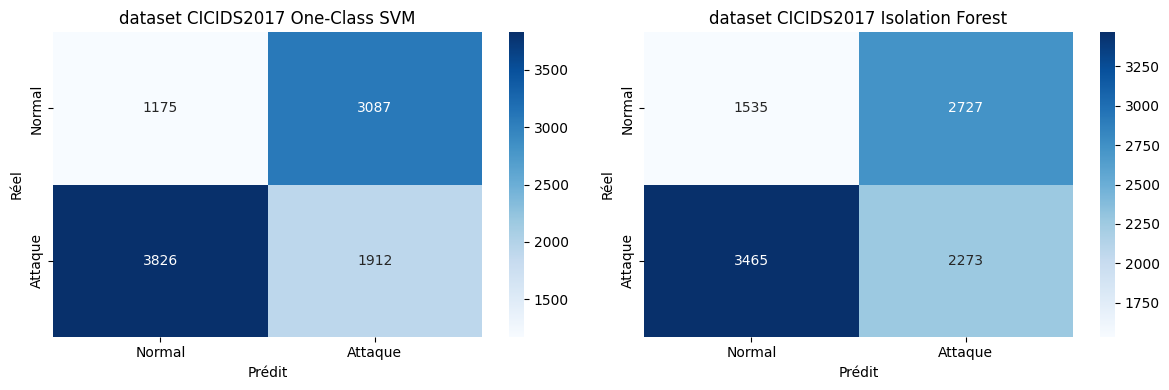

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, pred, title in zip([ax1, ax2], [pred_svm, pred_if], ['One-Class SVM', 'Isolation Forest']):
    sns.heatmap(confusion_matrix(y_cicids_sample, pred), annot=True, fmt='d', cmap='Blues', ax=ax,xticklabels=['Normal', 'Attaque'], yticklabels=['Normal', 'Attaque'])
    ax.set(title=f'dataset CICIDS2017 {title}', xlabel='Prédit', ylabel='Réel')
plt.tight_layout()
plt.show()

De même ici, sur les 4 262 connexions normales, les deux modèles en classent la majorité comme attaques (3 087 pour le SVM, 2 727 pour l'Isolation Forest) ainsi les faux positifs sont donc massifs dans les deux cas. Sur les 5 738 attaques réelles, l'Isolation Forest détecte légèrement plus d'attaques (2 273 contre 1 912 pour le SVM) mais les deux ratent plus de 60% des menaces réelles. L'Isolation Forest reste donc le meilleur des deux sur ce dataset, mais l'écart est faible et les performances globales sont insuffisantes. 


## Dataset 2 : UNSW-NB15

### 2.1 Préparation des données

In [7]:
# préparation features / label
X = df_unsw.drop(columns=['Label']).select_dtypes(include=[np.number])
y_unsw = df_unsw['Label']  # 0 pour normal et 1 pour attaque
X = X.fillna(0).replace([np.inf, -np.inf], 0)  # remplace valeurs manquantes et infinies par 0
X_unsw_scaled = StandardScaler().fit_transform(X)  # normalisation

# échantillon stratifié de 10 000 points
X_unsw_sample, _, y_unsw_sample, _ = train_test_split(X_unsw_scaled, y_unsw, train_size=10000, stratify=y_unsw, random_state=42)

print(f"Taille échantillon : {X_unsw_sample.shape}")
print(f"Proportion d'attaques : {y_unsw_sample.mean():.2%}")

Taille échantillon : (10000, 44)
Proportion d'attaques : 3.17%


### 2.2 Entraînement et comparaison

In [9]:
# One-Class SVM
t0 = time.time()
svm = OneClassSVM(kernel='rbf', nu=0.03, gamma='scale')  # nu =0.03 car 3% d'attaques
pred_svm = (svm.fit_predict(X_unsw_sample) == -1).astype(int)
t_svm = time.time() - t0

# Isolation Forest
t0 = time.time()
iforest = IsolationForest(contamination=0.03, random_state=42, n_jobs=-1)  # même valeur que nu
pred_if = (iforest.fit_predict(X_unsw_sample) == -1).astype(int)
t_if = time.time() - t0

print(f"Temps One-Class SVM : {t_svm:.2f}s")
print(f"Temps Isolation Forest : {t_if:.2f}s")
print(classification_report(y_unsw_sample, pred_svm, target_names=['Normal', 'Attaque']))
print(classification_report(y_unsw_sample, pred_if, target_names=['Normal', 'Attaque']))

Temps One-Class SVM : 3.36s
Temps Isolation Forest : 0.49s
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      9683
     Attaque       0.25      0.24      0.25       317

    accuracy                           0.95     10000
   macro avg       0.61      0.61      0.61     10000
weighted avg       0.95      0.95      0.95     10000

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      9683
     Attaque       0.34      0.32      0.33       317

    accuracy                           0.96     10000
   macro avg       0.66      0.65      0.65     10000
weighted avg       0.96      0.96      0.96     10000



Sur ce dataset les deux modèles obtiennent des résultats nettement meilleurs que sur CICIDS, en effet en termes de temps d'entraînement, le One-Class SVM prend 3.36s contre 0.49s pour l'Isolation Forest. Concernant les performances, les deux modèles classent très bien les connexions normales avec un f1 de 0.98, ce qui est attendu puisqu'elles représentent 97% du dataset. Sur les attaques en revanche, l'Isolation Forest obtient un f1 de 0.33 contre 0.25 pour le One-Class SVM, ce qui reste faible mais s'explique par le fort déséquilibre des classes avec seulement 317 attaques sur 10 000 points. L'Isolation Forest reste donc le meilleur des deux modèles sur ce dataset, aussi bien en termes de vitesse que de performance.

### 2.3 Matrices de confusion comparées

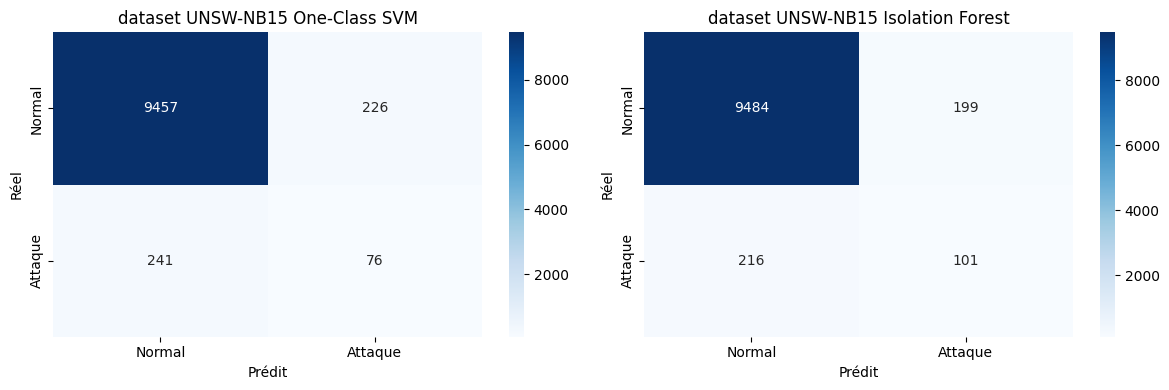

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, pred, title in zip([ax1, ax2], [pred_svm, pred_if], ['One-Class SVM', 'Isolation Forest']):
    sns.heatmap(confusion_matrix(y_unsw_sample, pred), annot=True, fmt='d', cmap='Blues', ax=ax,xticklabels=['Normal', 'Attaque'], yticklabels=['Normal', 'Attaque'])
    ax.set(title=f'dataset UNSW-NB15 {title}', xlabel='Prédit', ylabel='Réel')

plt.tight_layout()
plt.show()

Les deux modèles classent très bien les connexions normales avec 9 457 pour le SVM et 9 484 pour l'Isolation Forest sur 9 683 normaux.
Sur les attaques en revanche le SVM détecte seulement 76 attaques sur 317  et l'Isolation Forest 101 . L'Isolation Forest reste donc légèrement supérieur, mais les deux modèles ratent la grande majorité des menaces réelles, ce qui s'explique par le très faible nombre d'attaques dans l'échantillon (317 sur 10 000 points) rendant leur isolation difficile.


## Dataset 3 : Cybersecurity Threat Detection Logs

### 3.1 Préparation des données

De même que le dataset CICIDS le dataset Logs contient 6 millions de lignes donc on travaille sur un échantillon de 10 000 points.

In [13]:
# encodage des colonnes texte en nombres
df_enc = df_logs.copy()
for col in ['protocol', 'action', 'log_type']:
    if col in df_enc.columns:
        df_enc[col + '_enc'] = LabelEncoder().fit_transform(df_enc[col].astype(str))

# sélection des features et normalisation
features = ['bytes_transferred'] + [c for c in df_enc.columns if c.endswith('_enc')]
X = df_enc[features].fillna(0)
y = (df_logs['threat_label'] != 'benign').astype(int)  # 0 pour normal et 1 pour anomalie
X_logs_scaled = StandardScaler().fit_transform(X)


X_logs_sample, _, y_logs_sample, _ = train_test_split( X_logs_scaled, y, train_size=10000, stratify=y, random_state=42) # echantillon stratifié de 10 000 points

print(f"Taille échantillon : {X_logs_sample.shape}")
print(f"Proportion d'anomalies : {y_logs_sample.mean():.2%}")

Taille échantillon : (10000, 4)
Proportion d'anomalies : 8.04%


### 3.2 Entraînement et comparaison

In [14]:
# One-Class SVM
t0 = time.time()
svm = OneClassSVM(kernel='rbf', nu=0.08, gamma='scale')  # nu à 8% d'anomalies attendues
pred_svm = (svm.fit_predict(X_logs_sample) == -1).astype(int)  
t_svm = time.time() - t0

# Isolation Forest
t0 = time.time()
iforest = IsolationForest(contamination=0.08, random_state=42, n_jobs=-1)  # même valeur que nu
pred_if = (iforest.fit_predict(X_logs_sample) == -1).astype(int)
t_if = time.time() - t0

print(f"Temps One-Class SVM    : {t_svm:.2f}s")
print(f"Temps Isolation Forest : {t_if:.2f}s")
print(classification_report(y_logs_sample, pred_svm, target_names=['Normal', 'Anomalie']))
print(classification_report(y_logs_sample, pred_if, target_names=['Normal', 'Anomalie']))

Temps One-Class SVM    : 3.75s
Temps Isolation Forest : 1.12s
              precision    recall  f1-score   support

      Normal       0.92      0.92      0.92      9196
    Anomalie       0.08      0.08      0.08       804

    accuracy                           0.85     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.85      0.85      0.85     10000

              precision    recall  f1-score   support

      Normal       0.92      0.92      0.92      9196
    Anomalie       0.10      0.10      0.10       804

    accuracy                           0.86     10000
   macro avg       0.51      0.51      0.51     10000
weighted avg       0.86      0.86      0.86     10000



Sur le dataset Logs, les deux modèles donnent des résultats presque identiques les anomalies obtiennent un f1 de seulement 0.08 pour le SVM et 0.10 pour l'Isolation Forest donc les deux échouent complètement à détecter les menaces réelles.
En termes de temps, le SVM prend 3.75s contre 1.12s pour l'Isolation Forest, un écart faible mais l'Isolation Forest reste plus rapide. 
Ce résultat n'est pas surprenant car on savait déjà que les features de ce dataset (bytes_transferred, protocol, action, log_type) ne sont pas discriminantes ainsi le problème vient des données et non du choix de l'algorithme

### 3.3 Matrices de confusion comparées

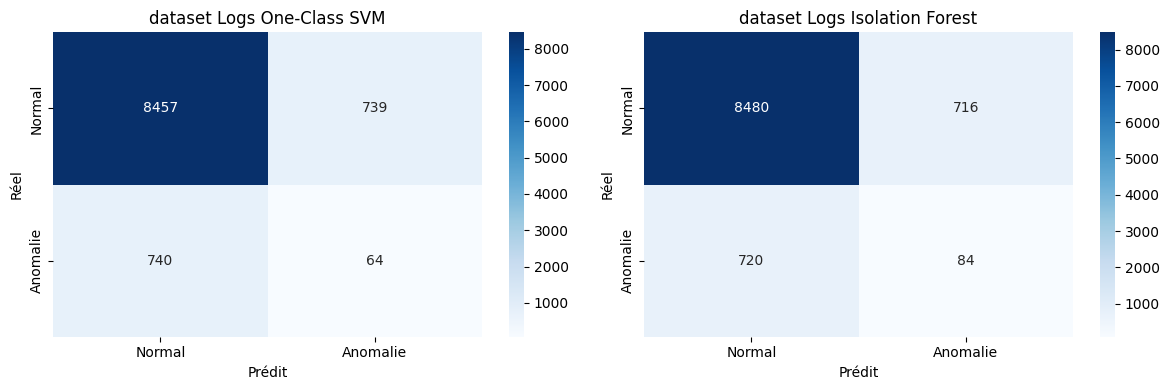

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, pred, title in zip([ax1, ax2], [pred_svm, pred_if], ['One-Class SVM', 'Isolation Forest']):
    sns.heatmap(confusion_matrix(y_logs_sample, pred), annot=True, fmt='d', cmap='Blues', ax=ax,xticklabels=['Normal', 'Anomalie'], yticklabels=['Normal', 'Anomalie'])
    ax.set(title=f'dataset Logs {title}', xlabel='Prédit', ylabel='Réel')
plt.tight_layout()
plt.show()

Les deux matrices sont presque identiques, ce qui confirme que les deux modèles se comportent de la même façon sur ce dataset. Sur les 804 anomalies réelles, le SVM en détecte seulement 64 et l'Isolation Forest 84. Les faux positifs sont également très nombreux avec 739 connexions normales faussement signalées pour le SVM et 716 pour l'Isolation Forest. Les features disponibles ne permettent à aucun des deux algorithmes de distinguer un trafic normal d'un trafic malveillant.


## Bilan 

On a tout au long de ce notebook remarqué que l'Isolation Forest est toujours plus rapide que le One-Class SVM. Cette différence s'explique par la complexité quadratique du SVM qui le rend peu adapté aux grands volumes de données.
En termes de performances, les deux modèles donnent des résultats très proches sur les trois datasets, avec un léger avantage pour l'Isolation Forest. Sur UNSW-NB15, les deux modèles obtiennent leurs meilleurs résultats avec un f1 allant jusqu'à 0.33 sur les attaques, ce dataset étant le mieux adapté à la détection d'anomalies car les attaques y sont réellement rares et isolées. Sur CICIDS2017, les deux algorithmes échouent car les attaques sont majoritaires  ce qui va à l'encontre du principe même de ces méthodes. Sur le dataset Logs les performances sont presque nulles sur les anomalies, le problème venant non pas des algorithmes mais du manque de features discriminantes.
En conclusion, l'Isolation Forest à l'air d'être le meilleur choix entre les deux étant plus rapide, aussi performant et plus adapté aux contraintes des grands datasets.